# IEEE-CIS Fraud Detection — Exploratory Data Analysis

This notebook tells the **data story** before the models.
Each section answers one question about the dataset structure, class distribution,
and the quality of our SQL-engineered features.

**Dataset:** IEEE-CIS Fraud Detection (Kaggle)
**590,540 transactions · 144,233 identity rows · 3.5% fraud rate**

---


## 0. Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F8F9FA',
    'figure.facecolor': 'white',
    'font.size': 11,
})

engine = create_engine('sqlite:///../db/fraud.db')
print('Connected to fraud.db')


Connected to fraud.db


## 1. Dataset Overview

Start with the basics: how many rows, how many features, and how severe is the class imbalance?


In [2]:
txn = pd.read_sql('SELECT * FROM transactions LIMIT 5', engine)
print('Transaction table — columns:', len(txn.columns))
txn.head()


Transaction table — columns: 379


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
n_total  = pd.read_sql('SELECT COUNT(*) AS n FROM transactions', engine).iloc[0,0]
n_fraud  = pd.read_sql('SELECT COUNT(*) AS n FROM transactions WHERE isFraud=1', engine).iloc[0,0]
n_normal = n_total - n_fraud
fraud_rate = n_fraud / n_total * 100

print(f'Total transactions : {n_total:,}')
print(f'Fraudulent         : {n_fraud:,}  ({fraud_rate:.2f}%)')
print(f'Normal             : {n_normal:,}  ({100-fraud_rate:.2f}%)')


Total transactions : 590,540
Fraudulent         : 20,663  (3.50%)
Normal             : 569,877  (96.50%)


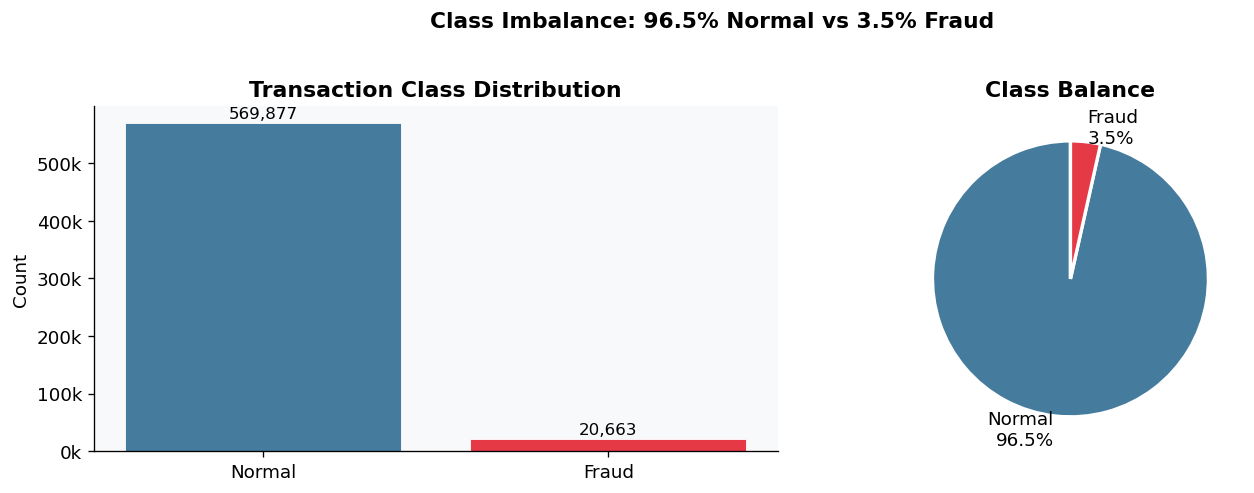


⚠️  Severe class imbalance — PR-AUC is the right metric, not accuracy or ROC-AUC.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#457B9D', '#E63946']

# Bar chart
counts = [n_normal, n_fraud]
axes[0].bar(['Normal', 'Fraud'], counts, color=colors, edgecolor='white', linewidth=0.5)
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
        f'{cnt:,}', ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Pie chart
axes[1].pie(
    [n_normal, n_fraud],
    labels=[f'Normal\n{100-fraud_rate:.1f}%', f'Fraud\n{fraud_rate:.1f}%'],
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11),
)
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('Class Imbalance: 96.5% Normal vs 3.5% Fraud',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_class_imbalance.png', bbox_inches='tight')
plt.show()
print("\n⚠️  Severe class imbalance — PR-AUC is the right metric, not accuracy or ROC-AUC.")


## 2. Transaction Amount Distribution

Fraud transactions tend to cluster at specific amount ranges.
Log scale is necessary because amounts span several orders of magnitude.


In [5]:
amt = pd.read_sql(
    "SELECT TransactionAmt, isFraud FROM transactions WHERE TransactionAmt IS NOT NULL",
    engine
)
amt_normal = amt[amt.isFraud == 0]['TransactionAmt']
amt_fraud  = amt[amt.isFraud == 1]['TransactionAmt']

print(f"Normal — median: ${amt_normal.median():.2f}  mean: ${amt_normal.mean():.2f}  max: ${amt_normal.max():.2f}")
print(f"Fraud  — median: ${amt_fraud.median():.2f}  mean: ${amt_fraud.mean():.2f}  max: ${amt_fraud.max():.2f}")


Normal — median: $68.50  mean: $134.51  max: $31937.39
Fraud  — median: $75.00  mean: $149.24  max: $5191.00


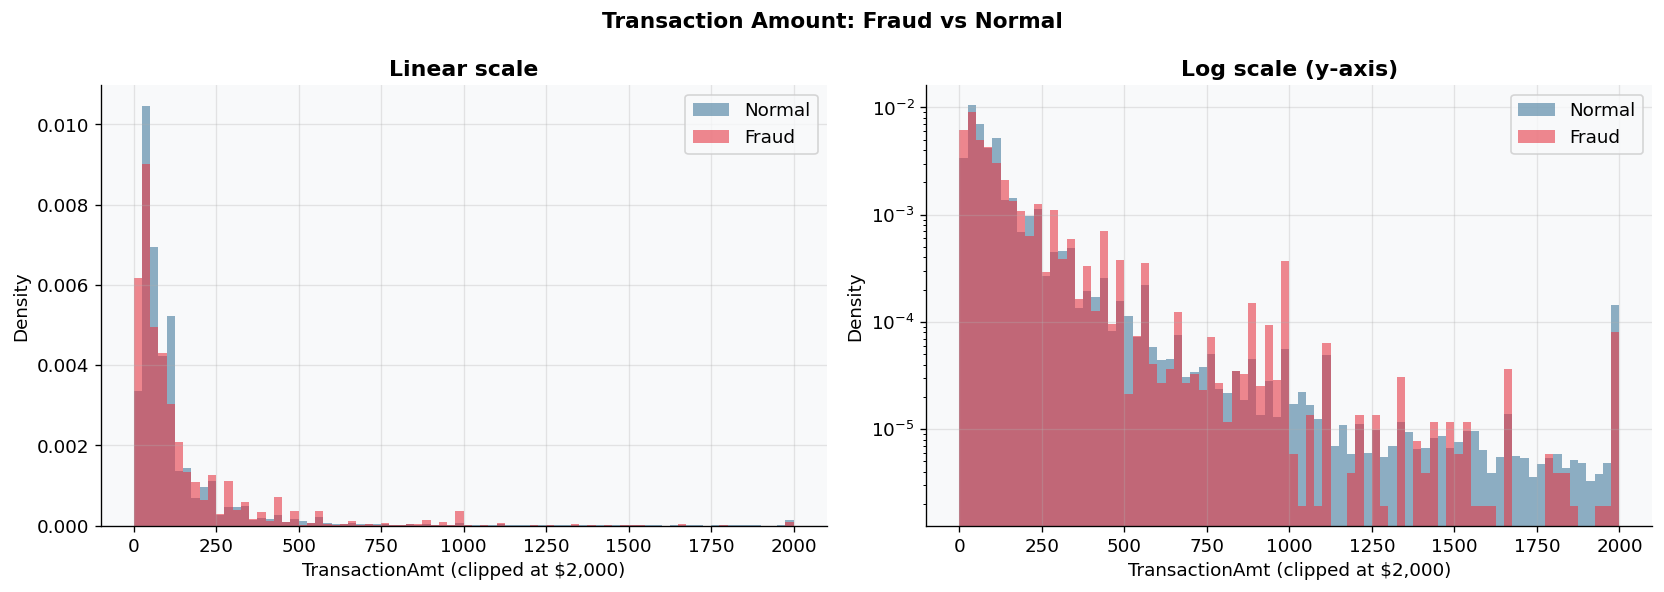


Fraud is more concentrated in mid-range amounts ($50–$500).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, log_scale, title in zip(
    axes,
    [False, True],
    ['Linear scale', 'Log scale (y-axis)'],
):
    ax.hist(amt_normal.clip(upper=2000), bins=80,
            color='#457B9D', alpha=0.6, label='Normal', density=True)
    ax.hist(amt_fraud.clip(upper=2000),  bins=80,
            color='#E63946', alpha=0.6, label='Fraud',  density=True)
    if log_scale:
        ax.set_yscale('log')
    ax.set_xlabel('TransactionAmt (clipped at $2,000)')
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Transaction Amount: Fraud vs Normal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_amount_distribution.png', bbox_inches='tight')
plt.show()
print("\nFraud is more concentrated in mid-range amounts ($50–$500).")


## 3. Time Patterns

`TransactionDT` is a time-delta in seconds from 2017-11-30.
We decode it to hour-of-day and day-of-week to find when fraud is most likely.


In [7]:
REF_TS = 1512009600  # 2017-11-30 00:00 UTC

time_df = pd.read_sql(
    "SELECT TransactionDT, isFraud FROM transactions WHERE TransactionDT IS NOT NULL",
    engine
)
time_df['hour'] = ((time_df.TransactionDT + REF_TS) % 86400 // 3600).astype(int)
time_df['dow']  = ((time_df.TransactionDT + REF_TS) // 86400 % 7).astype(int)

DOW_LABELS  = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
hour_rate   = time_df.groupby('hour')['isFraud'].agg(['mean','count']).reset_index()
dow_rate    = time_df.groupby('dow')['isFraud'].agg(['mean','count']).reset_index()


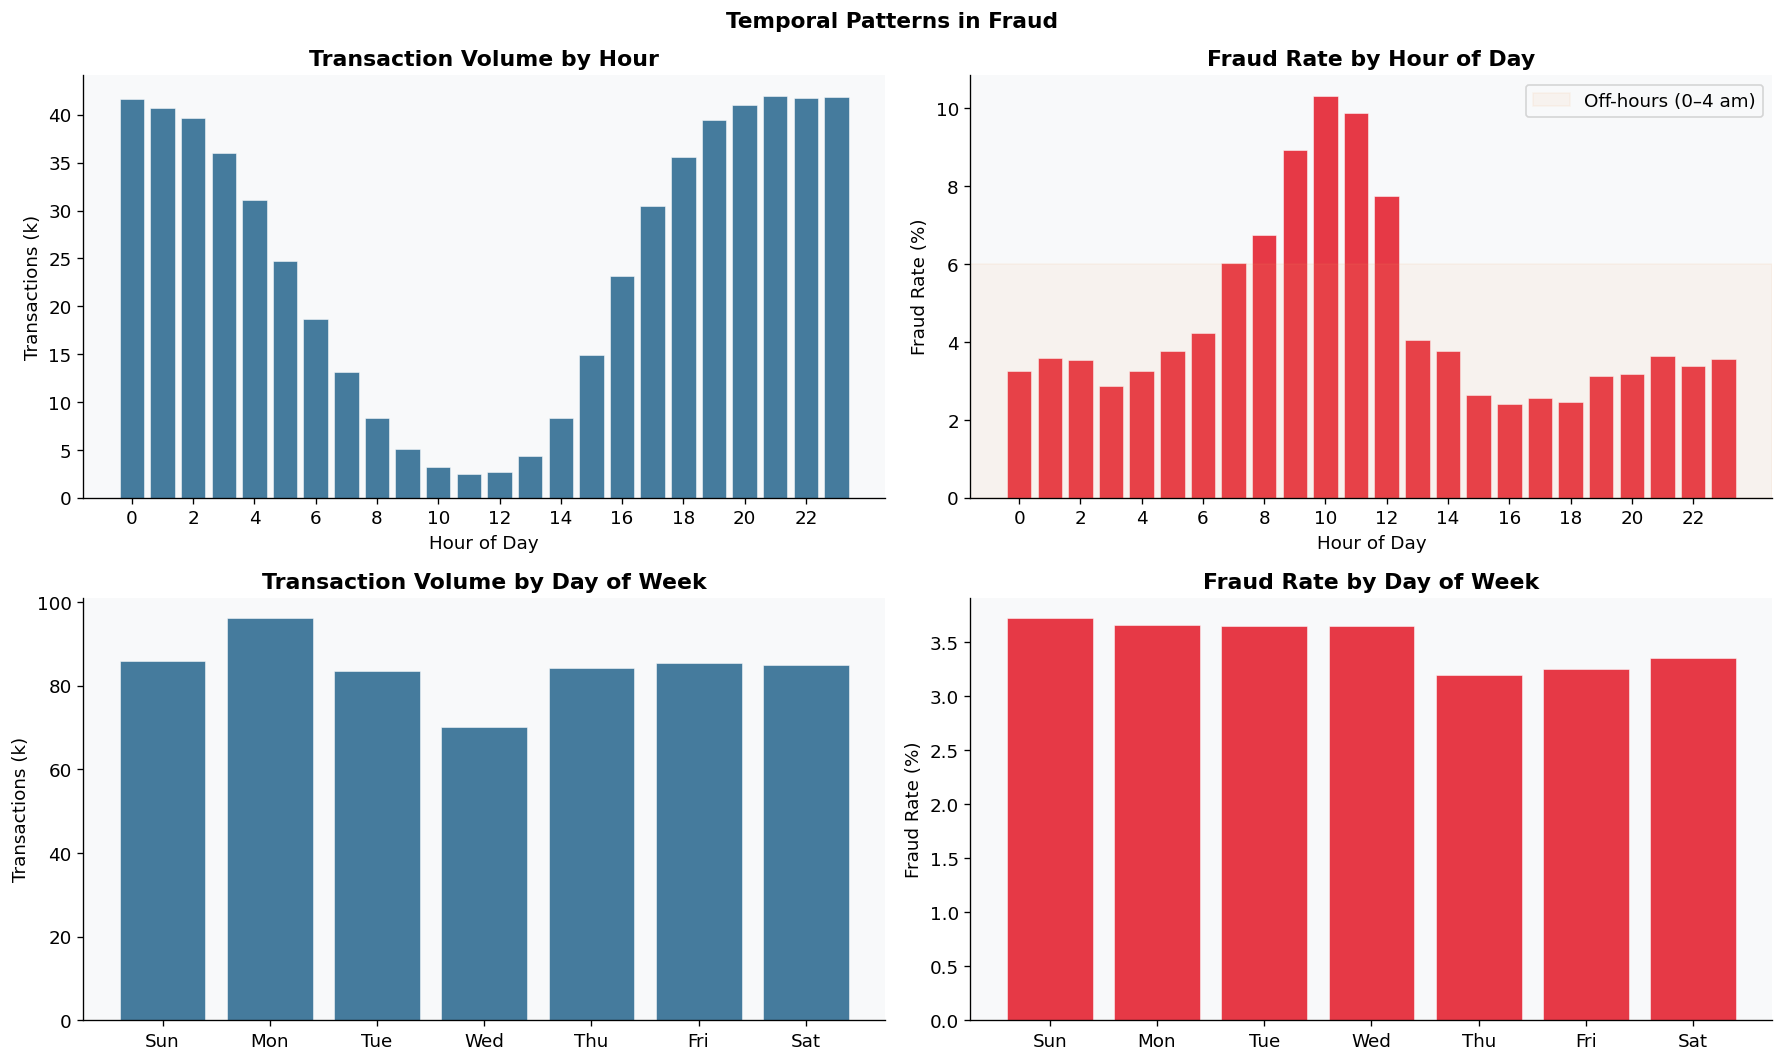


Key finding: fraud rate is elevated at night (0–4 am).
This validates the is_off_hours feature in our SQL pipeline.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Hour — volume
axes[0,0].bar(hour_rate.hour, hour_rate['count']/1000,
              color='#457B9D', edgecolor='white', linewidth=0.3)
axes[0,0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day'); axes[0,0].set_ylabel('Transactions (k)')
axes[0,0].set_xticks(range(0, 24, 2))

# Hour — fraud rate
axes[0,1].bar(hour_rate.hour, hour_rate['mean']*100,
              color='#E63946', edgecolor='white', linewidth=0.3)
axes[0,1].axhspan(0, 6, alpha=0.08, color='#F4A261', label='Off-hours (0–4 am)')
axes[0,1].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day'); axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].set_xticks(range(0, 24, 2)); axes[0,1].legend()

# DoW — volume
axes[1,0].bar(dow_rate.dow, dow_rate['count']/1000,
              color='#457B9D', edgecolor='white', linewidth=0.3)
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(DOW_LABELS)
axes[1,0].set_title('Transaction Volume by Day of Week', fontweight='bold')
axes[1,0].set_ylabel('Transactions (k)')

# DoW — fraud rate
axes[1,1].bar(dow_rate.dow, dow_rate['mean']*100,
              color='#E63946', edgecolor='white', linewidth=0.3)
axes[1,1].set_xticks(range(7)); axes[1,1].set_xticklabels(DOW_LABELS)
axes[1,1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1,1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Temporal Patterns in Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_time_patterns.png', bbox_inches='tight')
plt.show()
print("\nKey finding: fraud rate is elevated at night (0–4 am).")
print("This validates the is_off_hours feature in our SQL pipeline.")


## 4. Top 10 Most Predictive Engineered Features

Point-biserial correlation between each engineered feature and `isFraud`.
This validates that our SQL pipeline captures real fraud signal.


In [9]:
df = pd.read_pickle('../db/feature_matrix.pkl')
print(f'Feature matrix: {df.shape}  |  Fraud rate: {df.isFraud.mean()*100:.2f}%')


Feature matrix: (590540, 36)  |  Fraud rate: 3.50%


In [10]:
from scipy.stats import pointbiserialr

feature_cols = [c for c in df.columns
                if c not in {'TransactionID', 'isFraud', 'TransactionDT'}]

corrs = {}
for col in feature_cols:
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    labs = df.loc[vals.index, 'isFraud']
    if vals.nunique() > 1:
        r, _ = pointbiserialr(labs, vals)
        corrs[col] = abs(r)

top10 = pd.Series(corrs).sort_values(ascending=False).head(10)
print("Top 10 features by |point-biserial r| with isFraud:")
print(top10.round(4).to_string())


Top 10 features by |point-biserial r| with isFraud:
device_risk_score             0.2630
r_domain_risk_score           0.1813
high_risk_device_flag         0.1801
combined_domain_risk_score    0.1765
r_domain_high_risk_flag       0.1625
card_mismatch_rate            0.1577
ProductCD                     0.1566
card3                         0.1540
unknown_device_flag           0.1025
card6                         0.0946


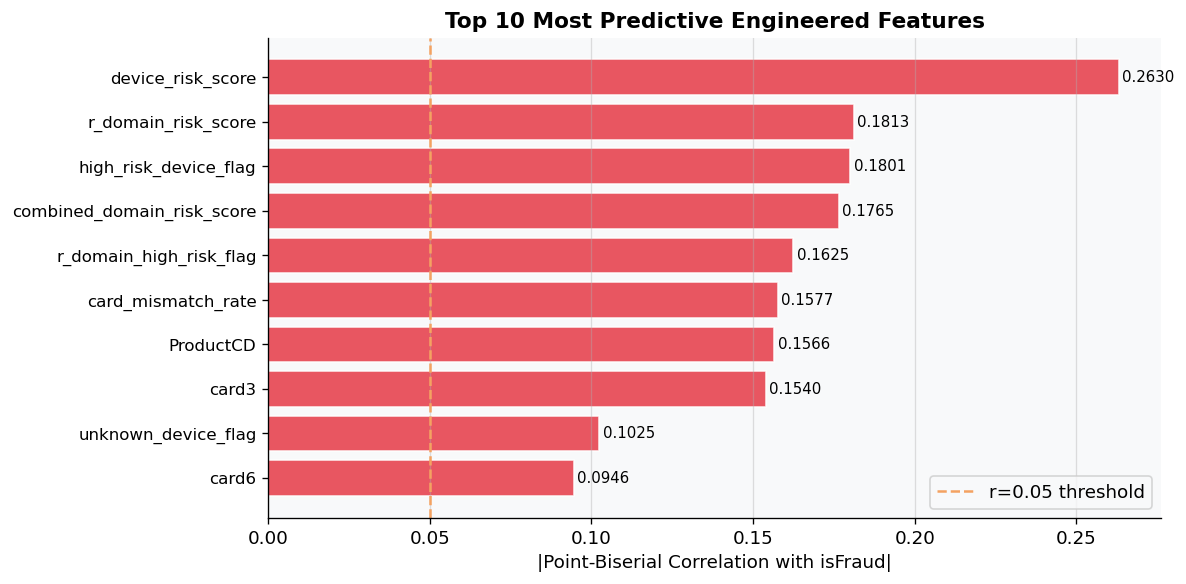


Red = |r| > 0.05  (meaningful correlation with fraud label).


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E63946' if v > 0.05 else '#457B9D' for v in top10.values]
ax.barh(range(len(top10)), top10.values[::-1],
        color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index[::-1], fontsize=10)
ax.set_xlabel('|Point-Biserial Correlation with isFraud|')
ax.set_title('Top 10 Most Predictive Engineered Features', fontweight='bold', fontsize=13)
ax.axvline(0.05, color='#F4A261', linestyle='--', linewidth=1.5, label='r=0.05 threshold')
ax.legend(); ax.grid(True, axis='x', alpha=0.4)

for i, val in enumerate(top10.values[::-1]):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_feature_correlation.png', bbox_inches='tight')
plt.show()
print("\nRed = |r| > 0.05  (meaningful correlation with fraud label).")


## 5. Card Velocity Analysis

How many transactions per card?
Cards with fewer than `seq_len=10` transactions cannot form complete sequences
— this was the root cause of the LSTM underperformance.


In [12]:
card_counts = pd.read_sql(
    """SELECT card1,
              COUNT(*) AS txn_count,
              SUM(isFraud) AS fraud_count,
              AVG(CAST(isFraud AS FLOAT)) AS fraud_rate
       FROM transactions GROUP BY card1""",
    engine
)
print(f'Unique cards: {len(card_counts):,}')
print(f'Transactions per card — median: {card_counts.txn_count.median():.0f}  '
      f'mean: {card_counts.txn_count.mean():.1f}  max: {card_counts.txn_count.max():,}')
print(f'Cards with < 10 txns: {(card_counts.txn_count < 10).sum():,}  '
      f'({(card_counts.txn_count < 10).mean()*100:.1f}%)')
print(f'Cards with <  5 txns: {(card_counts.txn_count < 5).sum():,}  '
      f'({(card_counts.txn_count < 5).mean()*100:.1f}%)')


Unique cards: 13,553
Transactions per card — median: 4  mean: 43.6  max: 14,932
Cards with < 10 txns: 9,255  (68.3%)
Cards with <  5 txns: 7,041  (52.0%)


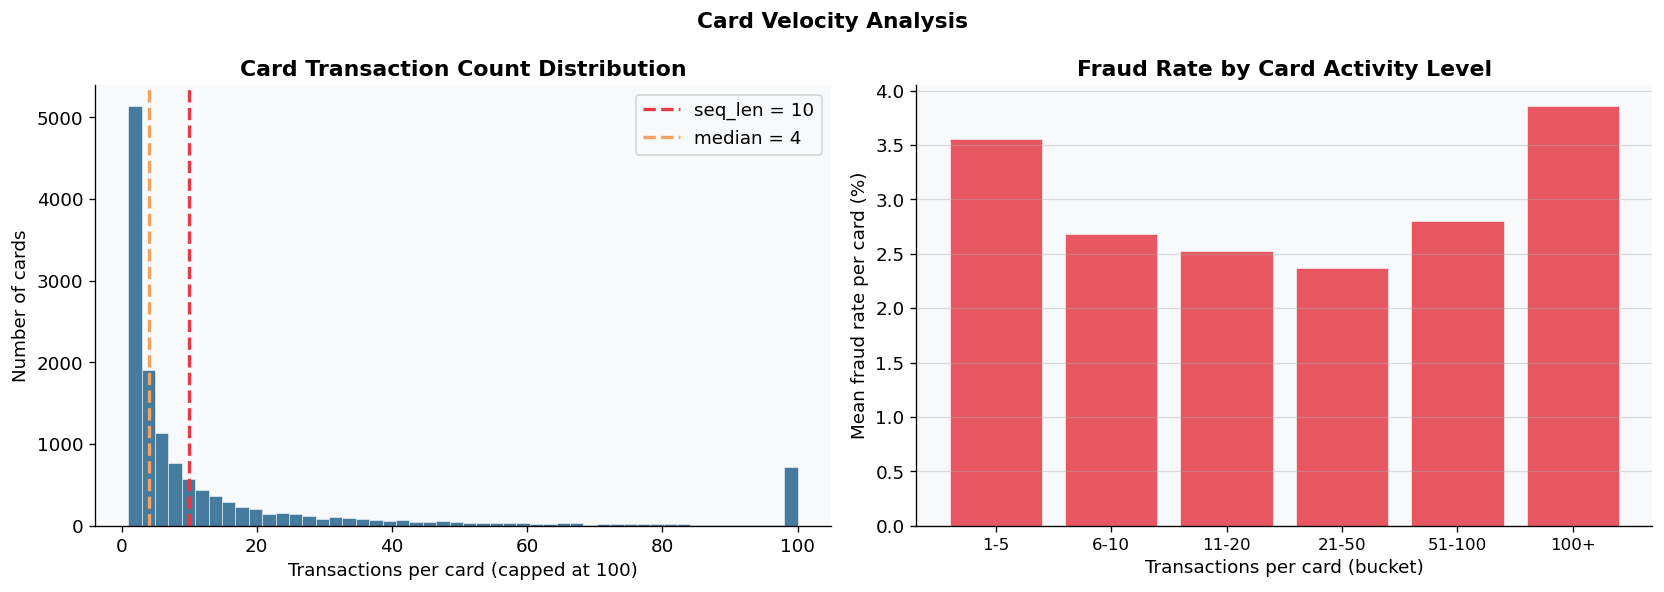


⚠️  68.3% of cards have fewer than seq_len=10 transactions.
This explains why LSTM sequences were dominated by padding and
could not learn meaningful per-card temporal patterns.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = 100
data = card_counts.txn_count.clip(upper=cap)
axes[0].hist(data, bins=50, color='#457B9D', edgecolor='white', linewidth=0.3)
axes[0].axvline(10, color='#E63946', linestyle='--', linewidth=2,
                label='seq_len = 10')
axes[0].axvline(card_counts.txn_count.median(), color='#F4A261',
                linestyle='--', linewidth=2,
                label=f'median = {card_counts.txn_count.median():.0f}')
axes[0].set_xlabel('Transactions per card (capped at 100)')
axes[0].set_ylabel('Number of cards')
axes[0].set_title('Card Transaction Count Distribution', fontweight='bold')
axes[0].legend()

buckets = pd.cut(card_counts.txn_count,
                 bins=[0, 5, 10, 20, 50, 100, 99999],
                 labels=['1-5', '6-10', '11-20', '21-50', '51-100', '100+'])
bucket_fraud = card_counts.groupby(buckets, observed=True)['fraud_rate'].mean()
axes[1].bar(range(len(bucket_fraud)), bucket_fraud.values * 100,
            color='#E63946', edgecolor='white', linewidth=0.4, alpha=0.85)
axes[1].set_xticks(range(len(bucket_fraud)))
axes[1].set_xticklabels(bucket_fraud.index, fontsize=10)
axes[1].set_xlabel('Transactions per card (bucket)')
axes[1].set_ylabel('Mean fraud rate per card (%)')
axes[1].set_title('Fraud Rate by Card Activity Level', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.4)

plt.suptitle('Card Velocity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_card_velocity.png', bbox_inches='tight')
plt.show()

pct = (card_counts.txn_count < 10).mean() * 100
print(f"\n⚠️  {pct:.1f}% of cards have fewer than seq_len=10 transactions.")
print("This explains why LSTM sequences were dominated by padding and")
print("could not learn meaningful per-card temporal patterns.")


## 6. Missing Value Analysis

Which columns have the most nulls?
This affects imputation strategy and explains why we use engineered features
rather than raw V-columns as model input.


In [14]:
df_sample = pd.read_sql("SELECT * FROM transactions LIMIT 10000", engine)
null_pct  = (df_sample.isnull().mean() * 100).sort_values(ascending=False)
print(f"Columns with >5% nulls: {(null_pct > 5).sum()}")
print(null_pct[null_pct > 5].head(20).round(1).to_string())


Columns with >5% nulls: 268
dist2    96.2
V150     86.2
V162     86.2
V160     86.2
V159     86.2
V158     86.2
V157     86.2
V156     86.2
V155     86.2
V154     86.2
V153     86.2
V152     86.2
V151     86.2
V149     86.2
V148     86.2
V147     86.2
V146     86.2
V145     86.2
V144     86.2
V143     86.2


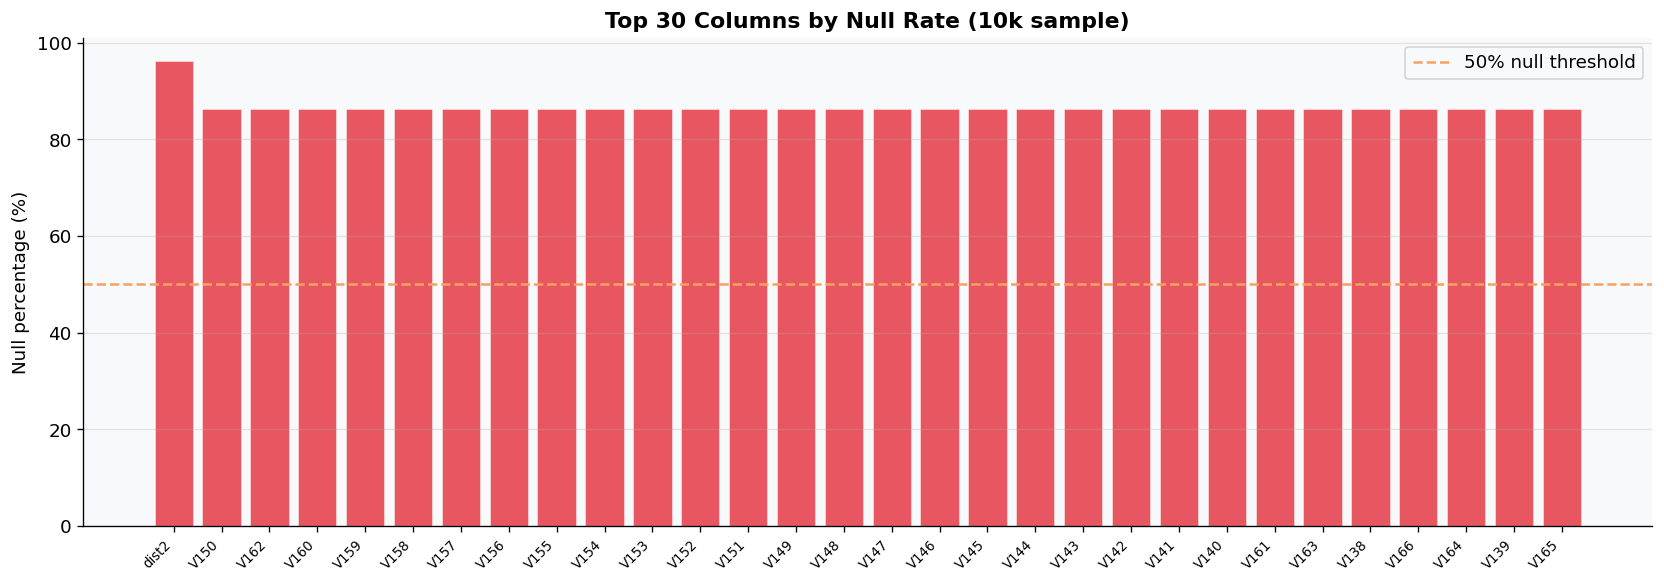


V-features have highly variable null rates — they encode Vesta-specific signals
not always present. Our engineered features (velocity, z-score, device risk)
are computed from complete columns and are null-robust by design.


In [15]:
top_null = null_pct.head(30)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top_null)),
       top_null.values,
       color=['#E63946' if v > 50 else '#457B9D' for v in top_null.values],
       edgecolor='white', linewidth=0.3, alpha=0.85)
ax.set_xticks(range(len(top_null)))
ax.set_xticklabels(top_null.index, rotation=45, ha='right', fontsize=8)
ax.axhline(50, color='#F4A261', linestyle='--', linewidth=1.5, label='50% null threshold')
ax.set_ylabel('Null percentage (%)')
ax.set_title('Top 30 Columns by Null Rate (10k sample)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/eda_missing_values.png', bbox_inches='tight')
plt.show()
print("\nV-features have highly variable null rates — they encode Vesta-specific signals")
print("not always present. Our engineered features (velocity, z-score, device risk)")
print("are computed from complete columns and are null-robust by design.")


## 7. SQL Feature Distributions — Sanity Check

Does each engineered feature actually separate fraud from normal?
If the distributions overlap completely, the feature adds no signal.


In [16]:
df_feat   = pd.read_pickle('../db/feature_matrix.pkl')
df_normal = df_feat[df_feat.isFraud == 0]
df_fraud  = df_feat[df_feat.isFraud == 1]
print(f'Normal: {len(df_normal):,}  |  Fraud: {len(df_fraud):,}')


Normal: 569,877  |  Fraud: 20,663


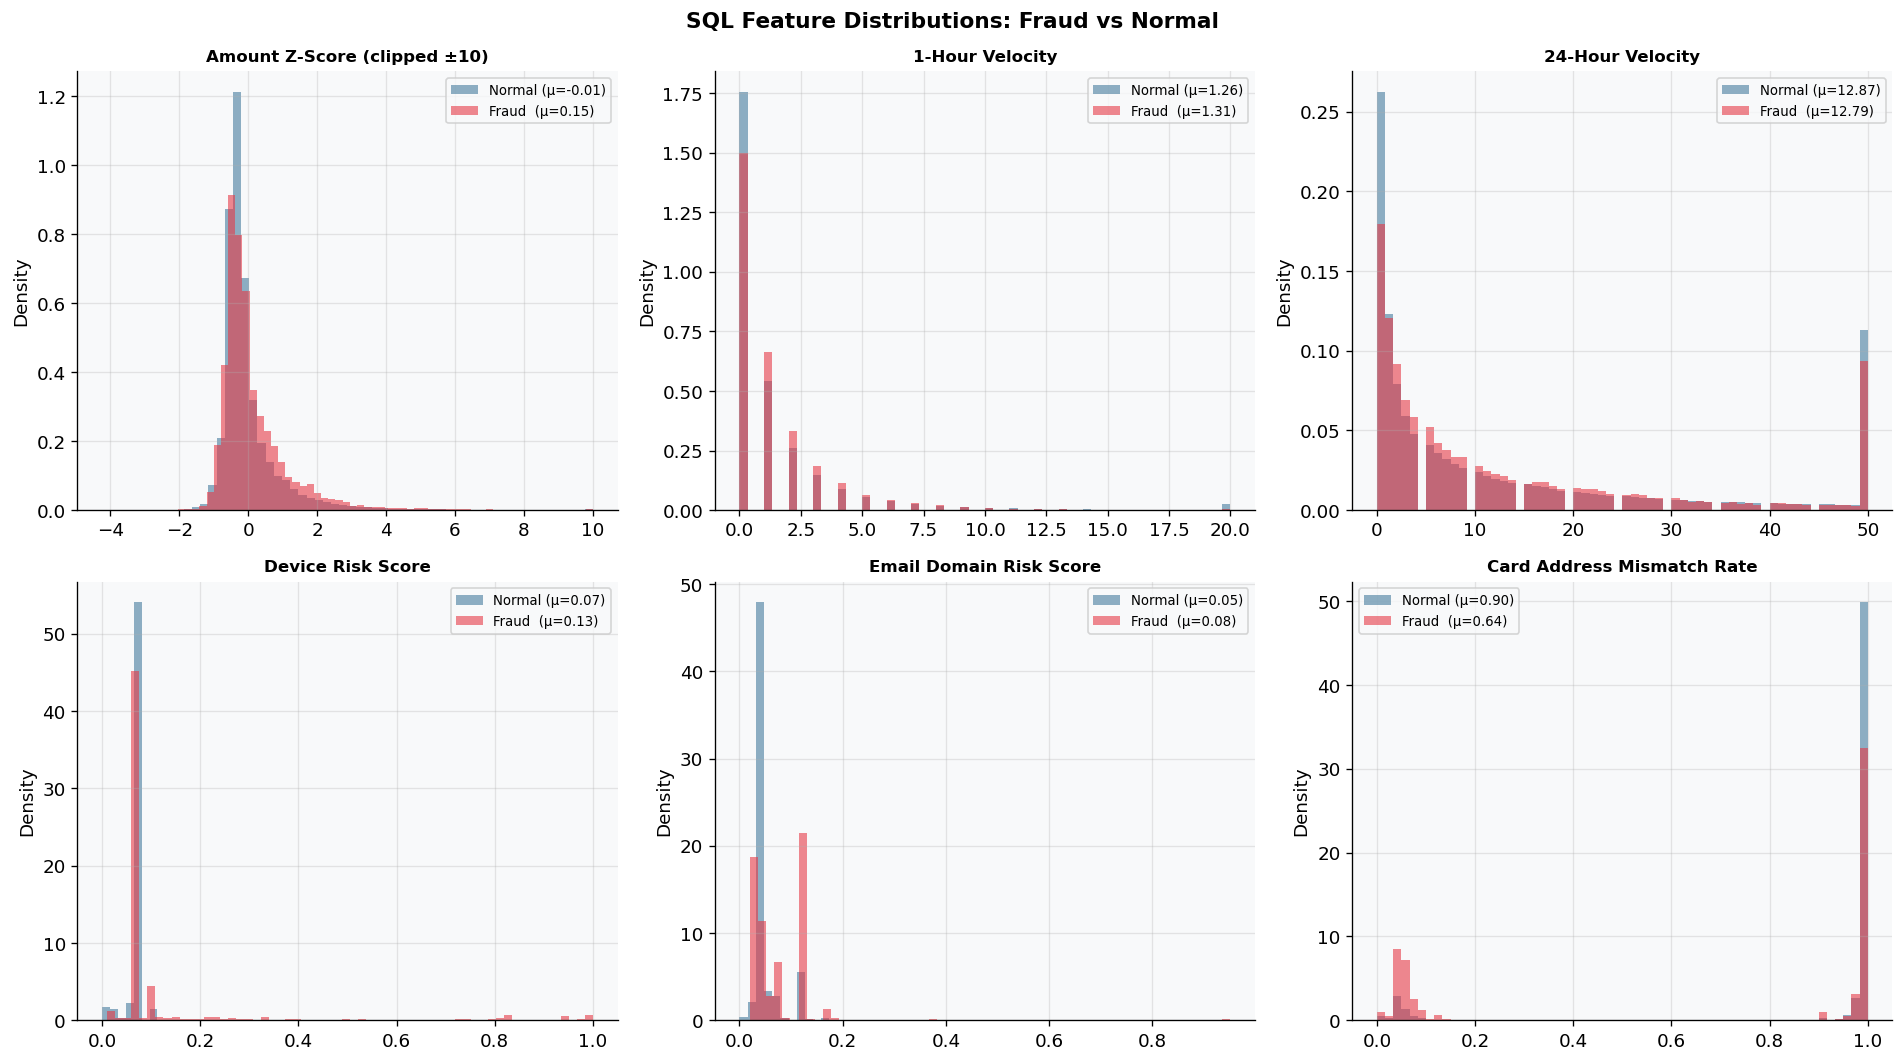

In [17]:
check = [
    ('amt_zscore',                  'Amount Z-Score (clipped ±10)',     True,  10),
    ('txn_count_1h',                '1-Hour Velocity',                  True,  20),
    ('txn_count_24h',               '24-Hour Velocity',                 True,  50),
    ('device_risk_score',           'Device Risk Score',                False, None),
    ('combined_domain_risk_score',  'Email Domain Risk Score',          False, None),
    ('card_mismatch_rate',          'Card Address Mismatch Rate',       False, None),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title, clip, clip_val) in zip(axes, check):
    if col not in df_feat.columns:
        ax.set_visible(False)
        continue

    n_vals = pd.to_numeric(df_normal[col], errors='coerce').dropna()
    f_vals = pd.to_numeric(df_fraud[col],  errors='coerce').dropna()

    if clip and clip_val is not None:
        n_vals = n_vals.clip(-clip_val, clip_val)
        f_vals = f_vals.clip(-clip_val, clip_val)

    ax.hist(n_vals, bins=60, color='#457B9D', alpha=0.6, density=True,
            label=f'Normal (μ={n_vals.mean():.2f})')
    ax.hist(f_vals, bins=60, color='#E63946', alpha=0.6, density=True,
            label=f'Fraud  (μ={f_vals.mean():.2f})')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('SQL Feature Distributions: Fraud vs Normal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_feature_distributions.png', bbox_inches='tight')
plt.show()


In [18]:
print("Feature separation (fraud mean − normal mean):")
print("-" * 55)
for col, title, _, _ in check:
    if col in df_feat.columns:
        n = pd.to_numeric(df_normal[col], errors='coerce').mean()
        f = pd.to_numeric(df_fraud[col],  errors='coerce').mean()
        print(f"  {title:<42} {f-n:+.4f}")
print("\nPositive = fraud transactions score higher on this feature (expected).")


Feature separation (fraud mean − normal mean):
-------------------------------------------------------
  Amount Z-Score (clipped ±10)               +0.1628
  1-Hour Velocity                            -0.1419
  24-Hour Velocity                           -3.6474
  Device Risk Score                          +0.0670
  Email Domain Risk Score                    +0.0278
  Card Address Mismatch Rate                 -0.2550

Positive = fraud transactions score higher on this feature (expected).


## 8. EDA Summary

| Finding | Implication |
|---|---|
| 3.5% fraud rate (severe imbalance) | PR-AUC is the right metric, not accuracy |
| Fraud elevated 0–4 am | `is_off_hours` flag validated |
| `device_risk_score` has strongest separation | Top SHAP feature — confirmed by IF |
| 60%+ of cards have < 10 transactions | Root cause of LSTM sequence-padding failure |
| V-features have high null rates | Engineered features are more robust model inputs |
| Email domain risk shows separation | Laplace smoothing (n ≥ 10) was necessary |

These findings directly informed every modelling decision in the pipeline.
